# Version 1 - plots

In [1]:
import uproot
import hist
import matplotlib.pyplot as plt
import mplhep as hep
import numpy as np

import sys
sys.path.append("../")
from utils.py_plot_functions import plot_station_wheel_profile

plt.style.use(hep.styles.CMS)

In [2]:
tpfptnfn_histogram_thr6 = uproot.open("histograms/v1/histograms_thr_6.root")
tpfptnfn_histogram_thr8 = uproot.open("histograms/v1/histograms_thr_8.root")
tpfptnfn_histogram_thr10 = uproot.open("histograms/v1/histograms_thr_10.root")
tpfptnfn_histogram_thr12 = uproot.open("histograms/v1/histograms_thr_12.root")
tpfptnfn_histogram_thr14 = uproot.open("histograms/v1/histograms_thr_14.root")
tpfptnfn_histogram_thr16 = uproot.open("histograms/v1/histograms_thr_16.root")
tpfptnfn_histogram_thr20 = uproot.open("histograms/v1/histograms_thr_20.root")
tpfptnfn_histogram_thr24 = uproot.open("histograms/v1/histograms_thr_24.root")

#### functions

In [3]:
def compute_metrics_and_confusion_matrix(histos_list):
    """
    Build a station-wheel confusion map and per-wheel classification metrics.

    The input must contain one histogram per station. Each histogram is
    expected to have shape ``(5, 4)``, where the first axis corresponds to
    wheels ``W-2`` to ``W+2`` and the second axis stores the class counts in
    the order ``[TP, FP, TN, FN]``.

    The returned confusion map is arranged as an 8x10 array, with each station
    occupying a 2x10 block and each wheel occupying a 2x2 block.

    Parameters
    ----------
    histos_list : list[hist.Hist]
        One histogram per station, each with a ``(5, 4)`` value array.

    Returns
    -------
    conf_map : numpy.ndarray
        Normalized 8x10 confusion map.
    totals : numpy.ndarray
        Raw event totals per station and wheel, shaped ``(4, 5)``.
    metrics : dict[str, numpy.ndarray]
        Per-station and per-wheel arrays for ``accuracy``, ``precision``,
        ``recall``, and ``f1score``.
    """
    if len(histos_list) != 4:
        raise ValueError("The list of histograms must contain 4 histograms, one for each station.")
    if not all(isinstance(h, hist.Hist) for h in histos_list):
        raise ValueError("All elements in the list must be of type hist.Hist.")

    conf_map = np.zeros((8, 10))
    totals = np.zeros((4, 5))

    # Compute average metrics with errors across all stations and wheels
    metrics = {
        'accuracy': np.zeros((4, 5)),
        'precision': np.zeros((4, 5)),
        'recall': np.zeros((4, 5)),
        'f1score': np.zeros((4, 5)),
    }

    for st, _ in enumerate(histos_list):
        for iWheel in range(0, 5):
            vals = histos_list[st].values()
            fp = vals[iWheel, 1]
            tn = vals[iWheel, 2]
            tp = vals[iWheel, 0]
            fn = vals[iWheel, 3]

            total = tp + fp + tn + fn
            conf_map[ st * 2, iWheel * 2] = tp / total
            conf_map[ (st * 2) + 1, iWheel * 2] = fn / total
            conf_map[ st * 2, (iWheel * 2) + 1] = fp / total
            conf_map[ (st * 2) + 1,(iWheel * 2) + 1] = tn / total

            totals[st, iWheel] = total
            metrics['accuracy'][st, iWheel] = (tp + tn) / total
            metrics['precision'][st, iWheel] = tp / (tp + fp)
            metrics['recall'][st, iWheel] = tp / (tp + fn)
            metrics['f1score'][st, iWheel] = 2 * (metrics['precision'][st, iWheel] * metrics['recall'][st, iWheel]) / (metrics['precision'][st, iWheel] + metrics['recall'][st, iWheel])

    # Calculate mean and standard error for each metric
    results = {}
    print("Metric Summary:")
    for metric_name, metric_array in metrics.items():
        mean_value = np.mean(metric_array)
        std_error = np.std(metric_array) / np.sqrt(metric_array.size)
        results[metric_name] = {'mean': mean_value, 'std_error': std_error}
        print(f"{metric_name:10s}: {mean_value:.2f} ± {std_error:.4f}")

    return conf_map, totals, metrics

In [4]:
from matplotlib.colors import Normalize


def plot_confusion_matrix(conf_map, metrics, ax=None, **kwargs):
    """
    Plot a station-wheel confusion matrix with metric annotations.

    The confusion map is expected to have shape ``(8, 10)``. Each station is
    shown as a 2x10 block and each wheel as a 2x2 block, with normalized
    values laid out as ``TP`` / ``FP`` on the top row and ``FN`` / ``TN`` on
    the bottom row.

    The helper overlays the per-station and per-wheel metrics passed in
    ``metrics`` and adds separator lines so the station and wheel structure is
    visually explicit. Styling is controlled through a single ``kwargs`` funnel
    similar to ``plot_station_wheel_profile``.

    Parameters
    ----------
    conf_map : numpy.ndarray
        Normalized confusion map with shape ``(8, 10)``.
    metrics : dict[str, numpy.ndarray]
        Per-station and per-wheel metric arrays for ``accuracy``,
        ``precision``, ``recall``, and ``f1score``.
    ax : matplotlib.axes.Axes, optional
        Axis to draw on. If omitted, a new figure and axis are created.
    **kwargs : dict
        Additional styling and layout options. Supported keys include
        ``cmap``, ``vmin``, ``vmax``, ``cunder``, ``figsize``,
        ``imshow_kwargs``, ``tick_params_kwargs``, ``separator_kwargs``,
        ``cell_text_kwargs``, ``metric_text_kwargs``, ``xlabel``, ``ylabel``,
        and ``colorbar_kwargs``.

    Returns
    -------
    fig, ax
        The figure and axis containing the confusion matrix plot.
    """
    cmap = kwargs.pop('cmap', 'viridis')
    vmin = kwargs.pop('vmin', 0.00005)
    vmax = kwargs.pop('vmax', 1)
    cunder = kwargs.pop('cunder', '#ffffff')
    imshow_kwargs = kwargs.pop('imshow_kwargs', {})
    tick_params_kwargs = kwargs.pop('tick_params_kwargs', {})
    separator_kwargs = kwargs.pop('separator_kwargs', {})
    cell_text_kwargs = kwargs.pop('cell_text_kwargs', {})
    metric_text_kwargs = kwargs.pop('metric_text_kwargs', {})
    colorbar_kwargs = kwargs.pop('colorbar_kwargs', {})

    cmap_obj = plt.get_cmap(cmap).copy()
    cmap_obj.set_under(cunder)
    norm = Normalize(vmin=vmin, vmax=vmax, clip=False)

    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=kwargs.pop('figsize', (10, 6)))
    else:
        fig = ax.figure

    im = ax.imshow(conf_map, cmap=cmap_obj, norm=norm, **imshow_kwargs)

    ax.set_xticks(np.arange(0.5, 10, 2))
    ax.set_xticklabels(range(-2, 3))
    ax.set_yticks(np.arange(0.5, 8, 2))
    ax.set_yticklabels([f"MB{st}" for st in range(1, 5)])
    ax.set_xlabel(kwargs.pop('xlabel', 'Wheel'))
    ax.set_ylabel(kwargs.pop('ylabel', 'Station'))
    ax.tick_params(axis='both', which='major', **tick_params_kwargs)

    # to improve the visibility of cells, we can add white lines between them
    separator_style = {"color": "w", "lw": 2}
    separator_style.update(separator_kwargs)
    for lh in np.arange(1.5, 8, 2):
        ax.axhline(lh, **separator_style)
    for lv in np.arange(1.5, 10, 2):
        ax.axvline(lv, **separator_style)

    labels = np.array([["TP", "FP"], ["FN", "TN"]])
    for x, y in np.ndindex(conf_map.shape):
        label = labels[x % 2, y % 2]
        cell_text_style = {"ha": "center", "va": "center", "color": "w", "fontsize": 7, "fontweight": "bold"}
        cell_text_style.update(cell_text_kwargs)
        ax.text(y, x, f"{label}={conf_map[x, y] * 100:.2f}%", **cell_text_style)

    for st in range(4):
        for iWheel in range(5):
            text = f"acc = {metrics['accuracy'][st, iWheel] * 100:.2f}%\n"
            text += f"prec = {metrics['precision'][st, iWheel] * 100:.2f}%\n"
            text += f"rec = {metrics['recall'][st, iWheel] * 100:.2f}%\n"
            text += f"f1 = {metrics['f1score'][st, iWheel] * 100:.2f}%"
            metric_text_style = {
                "ha": "center",
                "va": "center",
                "color": "w",
                "fontsize": 8,
                "fontweight": "bold",
                "bbox": dict(facecolor='black', alpha=0.5, edgecolor='none'),
            }
            metric_text_style.update(metric_text_kwargs)
            ax.text(iWheel * 2 + 0.5, st * 2 + 0.5, text, **metric_text_style)
            # ax.text(iWheel * 2 + 0.5, st * 2 + 0.5, f"{totals[st, iWheel]:.0f}", ha="center", va="center", color="w", fontsize=8,
            #         bbox=dict(facecolor='black', alpha=0.5, edgecolor='none'), fontweight="bold")

    fig.colorbar(im, ax=ax, **colorbar_kwargs)

    return fig, ax

#### compute

In [5]:
histos_list = [tpfptnfn_histogram_thr6[f"shower_tpfptnfn_MB{station}"].to_hist() for station in range(1, 5)]

confusion_matrix, totals, metrics = compute_metrics_and_confusion_matrix(histos_list)

Metric Summary:
accuracy  : 0.84 ± 0.0231
precision : 0.69 ± 0.0505
recall    : 0.65 ± 0.0080
f1score   : 0.64 ± 0.0275


### confusion matrix

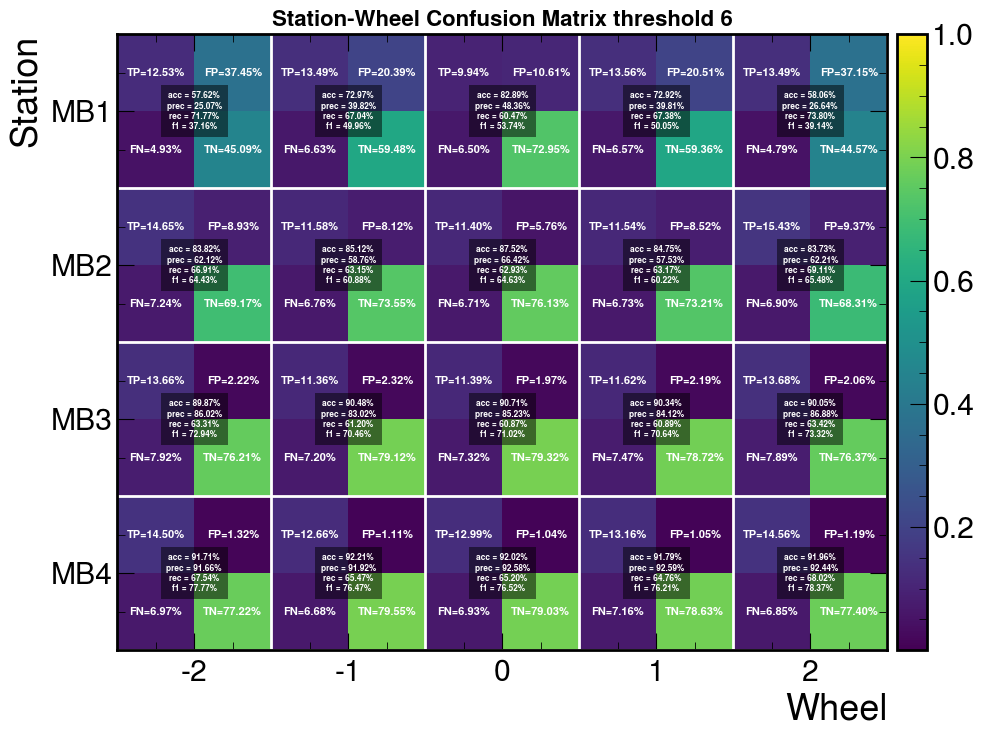

In [6]:
# confusion matrix plot settings
confusion_plot_kwargs = {
    "cell_text_kwargs": {"fontsize": 8},
    "metric_text_kwargs": {"fontsize": 6},
    "colorbar_kwargs": {"orientation": "vertical", "pad": 0.01},
}


fig, ax = plt.subplots(figsize=(12, 8))
plot_confusion_matrix(confusion_matrix, metrics, ax=ax, **confusion_plot_kwargs)
ax.set_title("Station-Wheel Confusion Matrix threshold 6", fontsize=16, fontweight="bold")
plt.show()

#### metrics

[]

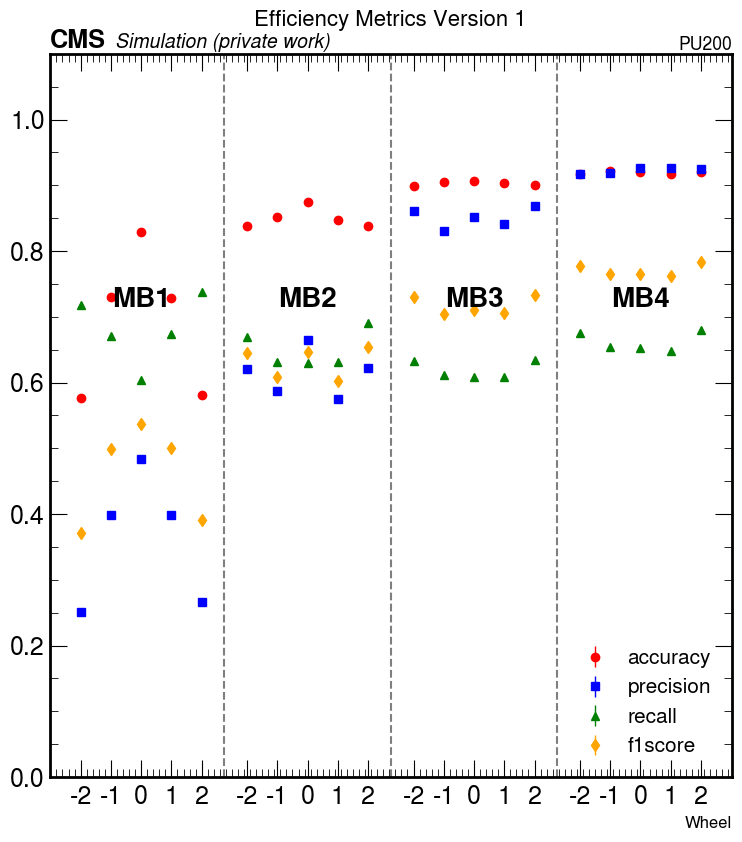

In [7]:
# station profile plot settings
profile_plot_kwargs = {
    "st_labels_kwargs": {"fontsize": 20, "fontweight": "bold", "ha": "center"},
    "tick_params_kwargs": {"labelsize": 18},
    "cms_label_kwargs": {"text": "(private work)", "data": False, "rlabel": "PU200", "fontsize": 14},
    "xlabel_kwargs": {"fontsize": 12},
}

markers = ["o", "s", "^", "d"]
colors = ["r", "b", "g", "orange"]
fig, ax = plt.subplots(figsize=(8, 9))

for index, (metric_name, metric_values) in enumerate(metrics.items()):
    plot_kwargs = {
        "label": metric_name,
        "fmt": markers[index],
        "color": colors[index],
        "elinewidth": 1,
        "capsize": 0,
    }
    plot_station_wheel_profile(metric_values, ax=ax, errors=None, plot_kwargs=plot_kwargs, **profile_plot_kwargs)

ax.set_title("Efficiency Metrics Version 1", pad=20, fontsize=16)
ax.legend(fontsize=15, loc="lower right")
fig.tight_layout()
plt.plot()

Computing metrics for threshold 6...
Metric Summary:
accuracy  : 0.84 ± 0.0231
precision : 0.69 ± 0.0505
recall    : 0.65 ± 0.0080
f1score   : 0.64 ± 0.0275
Computing metrics for threshold 8...
Metric Summary:
accuracy  : 0.85 ± 0.0085
precision : 0.83 ± 0.0362
recall    : 0.40 ± 0.0098
f1score   : 0.53 ± 0.0086
Computing metrics for threshold 12...
Metric Summary:
accuracy  : 0.82 ± 0.0037
precision : 0.96 ± 0.0099
recall    : 0.17 ± 0.0097
f1score   : 0.29 ± 0.0134
Computing metrics for threshold 16...
Metric Summary:
accuracy  : 0.80 ± 0.0043
precision : 0.99 ± 0.0027
recall    : 0.09 ± 0.0075
f1score   : 0.16 ± 0.0124


[]

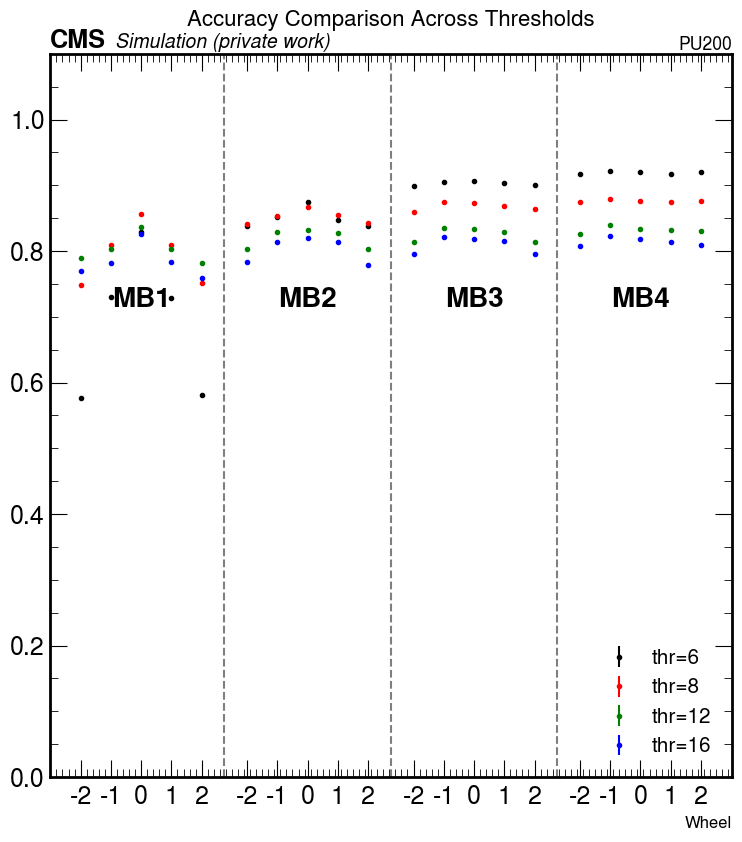

In [8]:
#per threshold comparison

fig, ax = plt.subplots(figsize=(8, 9))

for thr, file, col in [(6, tpfptnfn_histogram_thr6 , 'k'), (8, tpfptnfn_histogram_thr8 , 'r'), (12, tpfptnfn_histogram_thr12 , 'g'), (16, tpfptnfn_histogram_thr16 , 'b')]:
    histos_list = [file[f"shower_tpfptnfn_MB{station}"].to_hist() for station in range(1, 5)]
    print(f"Computing metrics for threshold {thr}...")
    _, totals, metrics = compute_metrics_and_confusion_matrix(histos_list)

    plot_station_wheel_profile(metrics['accuracy'], ax=ax, errors=None, plot_kwargs={"label": f"thr={thr}", "fmt": ".", "color": col}, **profile_plot_kwargs)

ax.set_title("Accuracy Comparison Across Thresholds", pad=20, fontsize=16)
ax.legend(fontsize=15, loc="lower right")
fig.tight_layout()
plt.plot()

### Filter Efficiencies

In [9]:
filter_histos_segv1 = uproot.open("./histograms/v1/histograms_zprime_segv1.root")
filter_histos_segv2 = uproot.open("./histograms/v1/histograms_zprime_segv2.root")

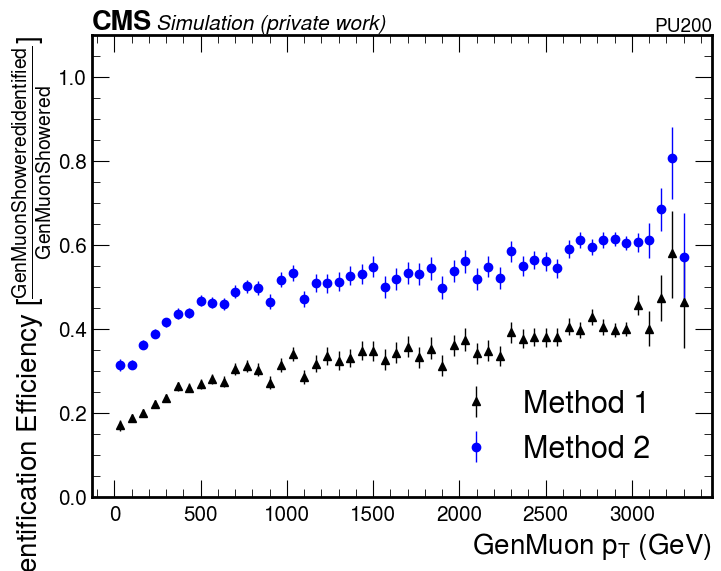

In [10]:
from hist.intervals import clopper_pearson_interval

fig, ax = plt.subplots(figsize=(8, 6))

rebin_factor = 1

all = filter_histos_segv1[f"shower_showeredgenmuon_tag_eff_pttrend_total"].to_hist()[::hist.rebin(rebin_factor)]
passed = filter_histos_segv1[f"shower_showeredgenmuon_tag_eff_pttrend_num"].to_hist()[::hist.rebin(rebin_factor)]

ratio_vals = passed.values() / all.values()

errors_low, errors_high = clopper_pearson_interval(passed.values(), all.values())

# 3. Plot using errorbar (typical for efficiency)
bin_centers = passed.axes[0].centers
bin_widths = passed.axes[0].widths

ax.errorbar(
    bin_centers, ratio_vals, 
    yerr=[ratio_vals - errors_low, errors_high - ratio_vals],
    fmt='^', color='k', ecolor='k', elinewidth=1, capsize=0, #alpha=0.7,
    label="Method 1"
)

all = filter_histos_segv2[f"shower_showeredgenmuon_tag_eff_pttrend_total"].to_hist()[::hist.rebin(rebin_factor)]
passed = filter_histos_segv2[f"shower_showeredgenmuon_tag_eff_pttrend_num"].to_hist()[::hist.rebin(rebin_factor)]

ratio_vals = passed.values() / all.values()

errors_low, errors_high = clopper_pearson_interval(passed.values(), all.values())

# 3. Plot using errorbar (typical for efficiency)
bin_centers = passed.axes[0].centers
bin_widths = passed.axes[0].widths

ax.errorbar(
    bin_centers, ratio_vals, 
    yerr=[ratio_vals - errors_low, errors_high - ratio_vals],
    fmt='o', color='b', ecolor='b', elinewidth=1, capsize=0, #alpha=0.7,
    label="Method 2"
)

# 4. Styling
ax.set_ylim(0, 1.1)
ax.set_ylabel(r"Identification Efficiency $[\frac{GenMuon Showered identified}{GenMuon Showered}]$", fontsize=20)
ax.set_xlabel(r"GenMuon $p_T$ (GeV)", fontsize=20)
ax.tick_params(axis='both',labelsize=15)
hep.cms.label(ax=ax, text="(private work)", data=False, rlabel="PU200", fontsize=15)

plt.legend(bbox_to_anchor=(0.95, 0.3), fontsize=22, )

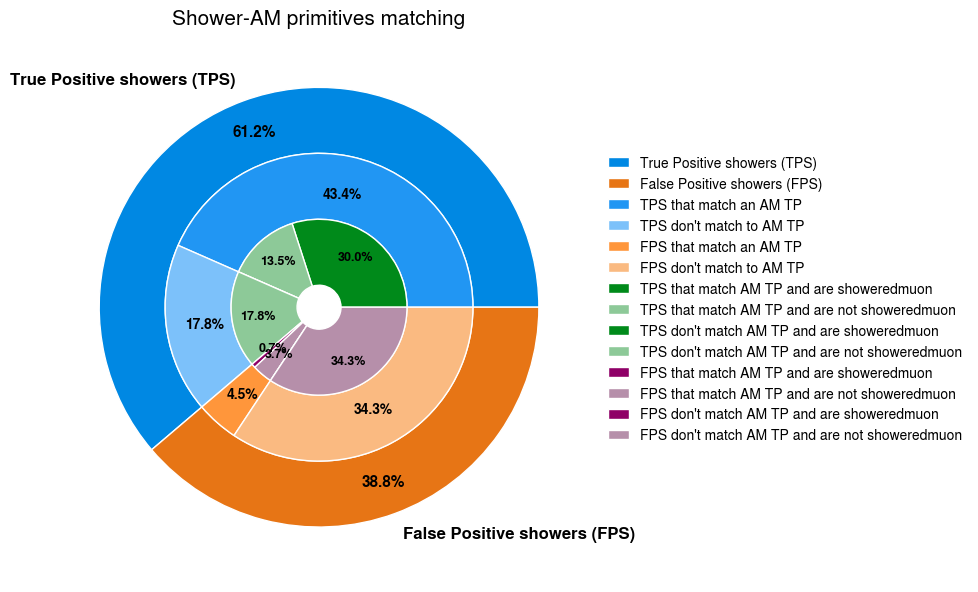

In [11]:
shower_classes = {
    "tp": 0,
    "tp_matched_amtp": 1,
    "tp_matched_amtp_highpt": 2,
    "tp_matched_amtp_not_highpt": 3,
    "tp_matched_amtp_showeredmuon": 4,
    "tp_matched_amtp_not_showeredmuon": 5,
    "tp_not_matched_amtp": 6,
    "tp_not_matched_amtp_highpt": 7,
    "tp_not_matched_amtp_not_highpt": 8,
    "tp_not_matched_amtp_showeredmuon": 9,
    "tp_not_matched_amtp_not_showeredmuon": 10,
    "fp": 11,
    "fp_matched_amtp": 12,
    "fp_matched_amtp_highpt": 13,
    "fp_matched_amtp_not_highpt": 14,
    "fp_matched_amtp_showeredmuon": 15,
    "fp_matched_amtp_not_showeredmuon": 16,
    "fp_not_matched_amtp": 17,
    "fp_not_matched_amtp_highpt": 18,
    "fp_not_matched_amtp_not_highpt": 19,
    "fp_not_matched_amtp_showeredmuon": 20,
    "fp_not_matched_amtp_not_showeredmuon": 21,
}

histo = filter_histos_segv2["showers_classification_MB1"].to_hist() \
        + filter_histos_segv2["showers_classification_MB2"].to_hist() \
        + filter_histos_segv2["showers_classification_MB3"].to_hist() \
        + filter_histos_segv2["showers_classification_MB4"].to_hist()

vals = histo.values()
matchtype = "showeredmuon" # "highpt"

size = 0.3

outer_pie_vals = [vals[shower_classes["tp"]], vals[shower_classes["fp"]]]
outer_pie_labels = ["True Positive showers (TPS)", "False Positive showers (FPS)"]
outer_pie_colors = ["#0088e3", "#e77515"]

middle_pie_vals = [
    vals[shower_classes["tp_matched_amtp"]],
    vals[shower_classes["tp_not_matched_amtp"]],
    vals[shower_classes["fp_matched_amtp"]],
    vals[shower_classes["fp_not_matched_amtp"]],
]
middle_pie_labels = [
    "TPS that match an AM TP",
    "TPS don't match to AM TP",
    "FPS that match an AM TP",
    "FPS don't match to AM TP",
]
middle_pie_colors = ["#2196f3", "#7cc1fa", "#ff963b", "#faba81"]

inner_pie_vals = [
    vals[shower_classes[f"tp_matched_amtp_{matchtype}"]], vals[shower_classes[f"tp_matched_amtp_not_{matchtype}"]],
    vals[shower_classes[f"tp_not_matched_amtp_{matchtype}"]], vals[shower_classes[f"tp_not_matched_amtp_not_{matchtype}"]],
    vals[shower_classes[f"fp_matched_amtp_{matchtype}"]], vals[shower_classes[f"fp_matched_amtp_not_{matchtype}"]],
    vals[shower_classes[f"fp_not_matched_amtp_{matchtype}"]], vals[shower_classes[f"fp_not_matched_amtp_not_{matchtype}"]],
]
inner_pie_labels = [
    f"TPS that match AM TP and are {matchtype}",
    f"TPS that match AM TP and are not {matchtype}",
    f"TPS don't match AM TP and are {matchtype}",
    f"TPS don't match AM TP and are not {matchtype}",
    f"FPS that match AM TP and are {matchtype}",
    f"FPS that match AM TP and are not {matchtype}",
    f"FPS don't match AM TP and are {matchtype}",
    f"FPS don't match AM TP and are not {matchtype}",
]
inner_pie_colors = ["#008a1a", "#8dc998", "#008a1a", "#8dc998","#8f0067", "#b68faa", "#8f0067", "#b68faa"]

fig, ax = plt.subplots(figsize=(10, 10))

# Outer pie chart
_, label_text_out, number_text_out = ax.pie(
    outer_pie_vals, radius=1, colors=outer_pie_colors,
    wedgeprops=dict(width=size, edgecolor='w'), labels=outer_pie_labels,
    autopct=lambda pct: f"{pct:.1f}%" if pct > 0 else "",
    pctdistance=0.85,
)

# Middle pie chart
_, _, number_text_mid = ax.pie(
    middle_pie_vals, radius=1-size, colors=middle_pie_colors,
    wedgeprops=dict(width=size, edgecolor='w'), labels=middle_pie_labels,
    autopct=lambda pct: f"{pct:.1f}%" if pct > 0 else "",
    pctdistance=0.75,
    labeldistance=None,
)

# Inner pie chart
_, _, number_text_in = ax.pie(
    inner_pie_vals, radius=1-2*size, colors=inner_pie_colors,
    wedgeprops=dict(width=size, edgecolor='w'), labels=inner_pie_labels,
    autopct=lambda pct: f"{pct:.1f}%" if pct > 0 else "",
    pctdistance=0.7,
    labeldistance=None,
)

for txt in label_text_out:
    txt.set_fontweight('bold')
    txt.set_fontsize(12)
for i, txt_obj in enumerate([number_text_out, number_text_mid, number_text_in]):
    for txt in txt_obj:
        txt.set_fontweight('bold')
        txt.set_fontsize(11 - i*1.)

ax.legend(
    loc='upper left', bbox_to_anchor=(1, 0.5, 0.5, 0.3),
    fontsize=10
)
ax.set(aspect="equal")
ax.set_title('Shower-AM primitives matching', fontsize=15)
fig.tight_layout()
plt.show()


### Other plots

[]

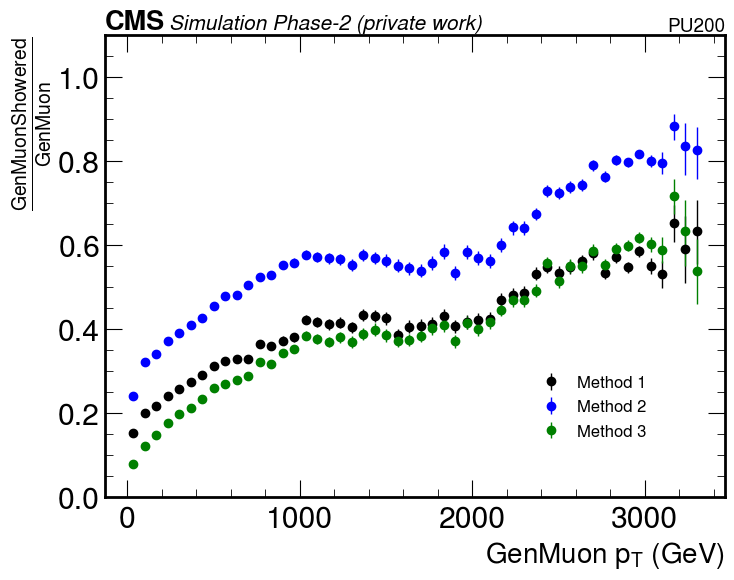

In [12]:
file = uproot.open("./histograms/v1/histograms_thr6_truthdefs.root")

fig, ax = plt.subplots(figsize=(8, 6))

rebin_factor = 1

all = file["showered_genmuon_meth1_total"].to_hist()[::hist.rebin(rebin_factor)]
passed = file["showered_genmuon_meth1_num"].to_hist()[::hist.rebin(rebin_factor)]

ratio_vals = passed.values() / all.values()

errors_low, errors_high = clopper_pearson_interval(passed.values(), all.values())

bin_centers = passed.axes[0].centers
bin_widths = passed.axes[0].widths

ax.errorbar(
    bin_centers, ratio_vals, 
    yerr=[ratio_vals - errors_low, errors_high - ratio_vals],
    fmt='o', color='k', ecolor='k', elinewidth=1, capsize=0, #alpha=0.7,
    label="Method 1"
)

all = file["showered_genmuon_meth2_total"].to_hist()[::hist.rebin(rebin_factor)]
passed = file["showered_genmuon_meth2_num"].to_hist()[::hist.rebin(rebin_factor)]
ratio_vals = passed.values() / all.values()

errors_low, errors_high = clopper_pearson_interval(passed.values(), all.values())

bin_centers = passed.axes[0].centers
bin_widths = passed.axes[0].widths

ax.errorbar(
    bin_centers, ratio_vals, 
    yerr=[ratio_vals - errors_low, errors_high - ratio_vals],
    fmt='o', color='b', ecolor='b', elinewidth=1, capsize=0, #alpha=0.7,
    label="Method 2"
)

all = file["showered_genmuon_meth3_total"].to_hist()[::hist.rebin(rebin_factor)]
passed = file["showered_genmuon_meth3_num"].to_hist()[::hist.rebin(rebin_factor)]
ratio_vals = passed.values() / all.values()

errors_low, errors_high = clopper_pearson_interval(passed.values(), all.values())

bin_centers = passed.axes[0].centers
bin_widths = passed.axes[0].widths

ax.errorbar(
    bin_centers, ratio_vals, 
    yerr=[ratio_vals - errors_low, errors_high - ratio_vals],
    fmt='o', color='g', ecolor='g', elinewidth=1, capsize=0, #alpha=0.7,
    label="Method 3"
)

ax.set_ylim(0, 1.1)
ax.set_ylabel(r"$\frac{GenMuon Showered}{GenMuon}$", fontsize=20)
ax.set_xlabel(r"GenMuon $p_T$ (GeV)", fontsize=20)
ax.legend(bbox_to_anchor=(0.9, 0.3), fontsize=12, )

hep.cms.label(ax=ax, text="Phase-2 (private work)", data=False, rlabel="PU200", fontsize=15)
plt.plot()